In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
# read in all the words

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of the characters and mappings to/from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [83]:
# build the dataset

block_size = 3 #context length
X,Y =  [], []

for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '------>', itos[ix])
        context = context[1:] +[ix]

        
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [162]:
#build the dataset

def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:

        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [42]:
C = torch.randn((27, 2))

In [43]:
C[5]

tensor([-1.1603,  0.8504])

In [44]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-1.1603,  0.8504])

In [45]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [46]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)


In [58]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

In [59]:
h.shape

torch.Size([32, 100])

In [61]:
h

tensor([[-0.9538, -0.4503,  0.6621,  ..., -0.4511,  0.9872, -0.8772],
        [-0.9593,  0.1547,  0.9631,  ...,  0.7211,  0.9983, -0.4725],
        [-0.9462,  0.9946,  0.9979,  ...,  0.9423,  0.9992, -0.8401],
        ...,
        [ 0.9293,  0.9240,  1.0000,  ...,  0.9999, -0.8347, -0.9999],
        [-1.0000, -1.0000,  0.9802,  ...,  0.6293,  0.5135,  0.9990],
        [-0.9968, -0.9143,  0.7374,  ..., -0.9429,  0.9978, -0.8907]])

In [62]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [63]:
logits = h@W2 +b2

In [64]:
logits.shape

torch.Size([32, 27])

In [65]:
counts = logits.exp()

In [66]:
prob = counts/counts.sum(1, keepdims=True)

In [67]:
prob.shape

torch.Size([32, 27])

In [68]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.3560)

In [35]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [163]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [207]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200,generator=g)
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [208]:
sum(p.nelement() for p in parameters) # total no parameters

11897

In [209]:
for p in parameters:
    p.requires_grad = True

In [210]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [211]:
lri = []
lossi = []
stepi = []

In [220]:

for i in range(50000):

    # minibatch selection
    ix =  torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30)@W1 +b1)
    logits = h@W2 +b2
    loss = F.cross_entropy(logits,Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad
    # #track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())


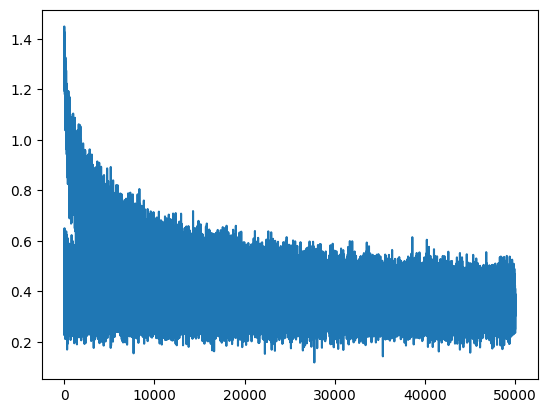

In [221]:
plt.plot(stepi,lossi)

In [222]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30)@W1 +b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1608, grad_fn=<NllLossBackward0>)

In [223]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30)@W1 +b1)
logits = h@W2 +b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1841, grad_fn=<NllLossBackward0>)

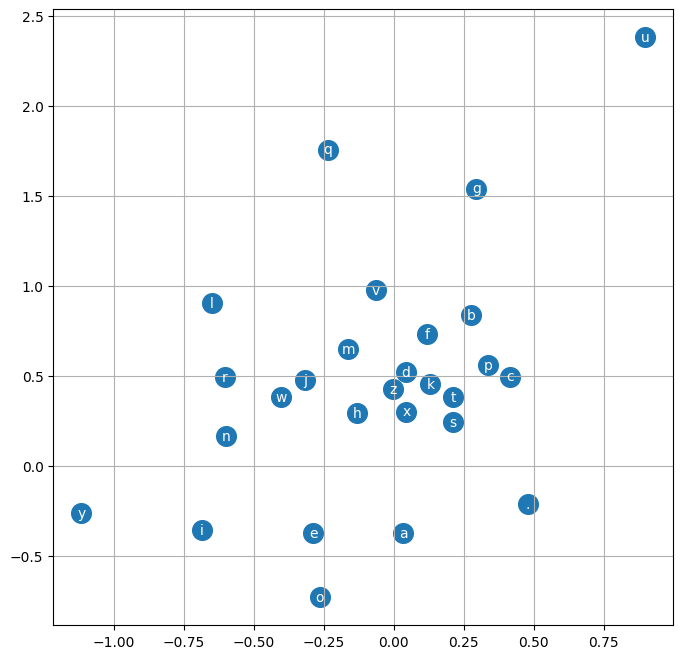

In [206]:
plt.figure(figsize=(8,8))

plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
    plt.grid('minor')